### **Parallel Workflows**

In [25]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict

In [26]:
llm = ChatOpenAI(model="gpt-5-mini", temperature=0)

In [27]:

class GraphSchema(TypedDict):
    topic: str
    insta: str
    linkedin: str
    twitter: str

In [28]:
def insta(state):
    insta_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'You are a post generator, who has to generate a post regarding the topic for instagram'),
            ('user', '{topic}')
        ]
    )

    chain = insta_prompt | llm
    insta_response = chain.invoke(
        {
            'topic': state['topic']
        }
    )

    return {'insta' : insta_response.content}

In [29]:
def linkedin(state):
    linkedin_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'You are a post generator, who has to generate a post regarding the topic for Linkedin'),
            ('user', '{topic}')
        ]
    )

    chain = linkedin_prompt | llm
    linkedin_response = chain.invoke(
        {
            'topic': state['topic']
        }
    )

    return {'linkedin' : linkedin_response.content}

In [30]:
def twitter(state):
    twitter_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'You are a post generator, who has to generate a post regarding the topic for twitter'),
            ('user', '{topic}')
        ]
    )

    chain = twitter_prompt | llm
    twitter_response = chain.invoke(
        {
            'topic': state['topic']
        }
    )
    
    return {'twitter': twitter_response.content}

In [31]:
parallel_graph = StateGraph(GraphSchema)
parallel_graph.add_node('insta', insta)
parallel_graph.add_node('linkedin', linkedin)
parallel_graph.add_node('twitter', twitter)

parallel_graph.add_edge(START, 'insta')
parallel_graph.add_edge(START, 'linkedin')
parallel_graph.add_edge(START, 'twitter')

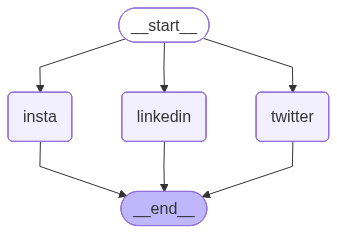

In [32]:
parallel_graph_compiled = parallel_graph.compile()
parallel_graph_compiled

In [33]:
parallel_graph_compiled.invoke(
    {
        'topic':'Messi vs Ronaldo',
        'insta': '',
        'linkedin': '',
        'twitter': ''

    }
)

{'topic': 'Messi vs Ronaldo',
 'insta': 'Caption:\nMessi vs Ronaldo — two eras, two styles, one endless debate. 🐐⚽️  \nThe magician with the vision and silky dribbles vs the unstoppable machine with power and clutch goals. Who wins your GOAT vote? ❤️ for Messi, 🔥 for Ronaldo — tell us why in the comments.\n\nSuggested image/video:\n- Split image: Messi on left, Ronaldo on right with a dramatic background (stadium lights)  \n- Or a short reel montage: best dribbles & assists (Messi) vs best free-kicks & volleys (Ronaldo)\n\nHashtags:\n#Messi #Ronaldo #GOATDebate #FootballLegends #Soccer #Futbol #GOAT #MessivsRonaldo\n\nOptional add-ons (use in Stories or comments):\n- Poll sticker: “Who’s the GOAT?” Messi / Ronaldo  \n- Tag fan accounts or teammates relevant to your audience',
 'linkedin': 'Messi vs Ronaldo — the football debate that never gets old. But on LinkedIn, the more useful question isn’t “who’s better?” — it’s “what can we learn from two of the world’s best performers?”\n\nA fe